# S1 Backtest — Weighting bake-off (IS)

Set **`N_STAR`** and **`TIMING_STAR`** by hand from notebooks 01–02.
On **research IS only**, compare sleeve weighting modes at the frozen N / timing.

| Mode | Within long / short sleeve |
|---|---|
| `equal` | Equal weight (baseline) |
| `score` | ∝ score (long) / ∝ |score| (short) |
| `rank` | ∝ cross-sectional rank within sleeve |
| `inv_vol` | ∝ 1/σ |

### Inverse-vol note

`inv_vol` in the mode bake-off (§2) uses the default **21 trading-day** trailing
**open-to-open** realized volatility from
`data.processing.feature_implementation.realized_vol`
(`DEFAULT_OPEN_VOL_WINDOW=21`), with **PIT `shift(1)`** so entry date `d` only
sees bars before `d` (S1 pre-open). The notebook does not recompute vol locally.

**§5** then screens inv-vol windows `{5, 10, 21, 42, 63}` on **IS net Sharpe**
and prints **`INV_VOL_WINDOW_STAR`**. OOS is not used here (sealed until notebook 08).

Pick **`WEIGHT_STAR`** by **IS net Sharpe** (§2). If that mode is `inv_vol`, also
copy `INV_VOL_WINDOW_STAR` into later notebooks. Copy into `05_stop_bakeoff`,
`06_pct_stop_bakeoff`, `07_vol_target_bakeoff`, and `08_oos_tearsheet`.

## Costs

Alpaca-representative open/close one-way bps (same as notebooks 01–02).


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.portfolio import (
    WEIGHT_EQUAL,
    WEIGHT_INV_VOL,
    WEIGHT_RANK,
    WEIGHT_SCORE,
    summarize_concentration,
    weight_concentration_stats,
)
from backtest.s1_equities.report import plot_equity_overlay
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_FRI_CLOSE,
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    prediction_path_for_timing,
    score_matrix,
)
from data.processing.feature_implementation.realized_vol import DEFAULT_OPEN_VOL_WINDOW

PATHS = default_backtest_paths(ROOT)

# --- Set from notebooks 01 / 02 ---
N_STAR = 15
TIMING_STAR = TIMING_MON_OPEN_MON_OPEN  # or TIMING_MON_OPEN_FRI_CLOSE

WEIGHT_MODES = [WEIGHT_EQUAL, WEIGHT_SCORE, WEIGHT_RANK, WEIGHT_INV_VOL]
INV_VOL_WINDOWS = [5, 10, 21, 42, 63]
PRED_PATH = prediction_path_for_timing(PATHS, TIMING_STAR)

print(f"N_STAR={N_STAR} (notebook parameter)")
print(f"TIMING_STAR={TIMING_STAR} (notebook parameter)")
print(f"predictions={PRED_PATH}")
print(f"inv_vol default window={DEFAULT_OPEN_VOL_WINDOW}d (§2); screen windows={INV_VOL_WINDOWS} (§5)")
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


N_STAR=15 (notebook parameter)
TIMING_STAR=mon_open_mon_open (notebook parameter)
predictions=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet
inv_vol default window=21d (§2); screen windows=[5, 10, 21, 42, 63] (§5)


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Load scores & prices


In [2]:
preds = load_predictions(PRED_PATH)
scores = score_matrix(preds)
is_mask = is_mask_from_preds(preds)
opens, highs, lows, closes = load_ohlc_panels(PATHS["features"], tickers=list(scores.columns))
print(f"scores={scores.shape}  IS dates={int(is_mask.sum())}")


scores=(592, 68)  IS dates=411


## 2. IS bake-off at N* / TIMING*


In [3]:
results = {}
rows = []
for mode in WEIGHT_MODES:
    res = run_backtest(
        scores,
        opens,
        closes,
        n=N_STAR,
        timing_mode=TIMING_STAR,
        weight_mode=mode,
        costs=DEFAULT_COSTS,
        date_mask=is_mask,
    )
    results[mode] = res
    sm = summarize_periods(res.period_returns)
    sm_g = summarize_periods(res.period_returns_gross)
    rows.append(
        {
            "weight_mode": mode,
            "n": N_STAR,
            "timing_mode": TIMING_STAR,
            "sharpe": sm["sharpe"],
            "cagr": sm["cagr"],
            "total_return": sm["total_return"],
            "max_drawdown": sm["max_drawdown"],
            "vol": sm["vol"],
            "win_rate": sm["win_rate"],
            "mean_turnover": float(res.turnover.mean()) if len(res.turnover) else np.nan,
            "n_periods": sm["n_periods"],
            "sharpe_gross": sm_g["sharpe"],
            "total_return_gross": sm_g["total_return"],
        }
    )
    print(
        f"{mode}: sharpe={sm['sharpe']:.3f}  cagr={sm['cagr']:.3%}  "
        f"dd={sm['max_drawdown']:.3%}  turn={res.turnover.mean():.3f}"
    )

bake_df = pd.DataFrame(rows).set_index("weight_mode")
display(bake_df)

best_mode = bake_df["sharpe"].idxmax()
WEIGHT_STAR = str(best_mode)
print(f"Suggested WEIGHT_STAR={WEIGHT_STAR}  (IS net Sharpe={bake_df.loc[WEIGHT_STAR, 'sharpe']:.4f})")
print("Copy this string into WEIGHT_STAR in notebooks 05 and 06.")


equal: sharpe=0.765  cagr=7.016%  dd=-26.375%  turn=0.128
score: sharpe=0.769  cagr=7.048%  dd=-26.284%  turn=0.131
rank: sharpe=0.851  cagr=9.145%  dd=-31.373%  turn=0.172
inv_vol: sharpe=0.922  cagr=7.245%  dd=-20.662%  turn=0.189


,n,timing_mode,sharpe,cagr,total_return,max_drawdown,vol,win_rate,mean_turnover,n_periods,sharpe_gross,total_return_gross
weight_mode,,,,,,,,,,,,
equal,15,mon_open_mon_open,0.765498,0.070164,0.706892,-0.263752,0.094487,0.592683,0.128130,410,0.874607,0.851468
score,15,mon_open_mon_open,0.768839,0.070477,0.710826,-0.262837,0.094452,0.590244,0.131454,410,0.880830,0.859655
rank,15,mon_open_mon_open,0.850792,0.091454,0.993686,-0.313734,0.110068,0.578049,0.171860,410,0.976607,1.223350
inv_vol,15,mon_open_mon_open,0.921772,0.072451,0.735863,-0.206625,0.079350,0.609756,0.189361,410,1.114282,0.957522


Suggested WEIGHT_STAR=inv_vol  (IS net Sharpe=0.9218)
Copy this string into WEIGHT_STAR in notebooks 05 and 06.


## 3. Weight concentration diagnostics

Per-date active-book stats (max/min |w|, sleeve max share of the ±0.5 budget, HHI).
Use mean / p95 / max of `max_abs_w` to judge whether a future max-weight cap is warranted —
no hard cap is applied here.


,n_dates,max_abs_w_mean,max_abs_w_p50,max_abs_w_p95,max_abs_w_max,min_abs_w_mean,hhi_mean,long_max_share_mean,long_max_share_max,short_max_share_mean,short_max_share_max
equal,411.0,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.066667,0.066667,0.066667,0.066667
score,411.0,0.034494,0.034437,0.035078,0.035658,0.032134,0.033343,0.068958,0.071317,0.068069,0.069239
rank,411.0,0.062500,0.062500,0.062500,0.062500,0.004167,0.043056,0.125000,0.125000,0.125000,0.125000
inv_vol,411.0,0.064161,0.061925,0.083267,0.099862,0.012047,0.038492,0.115637,0.191830,0.122137,0.199724


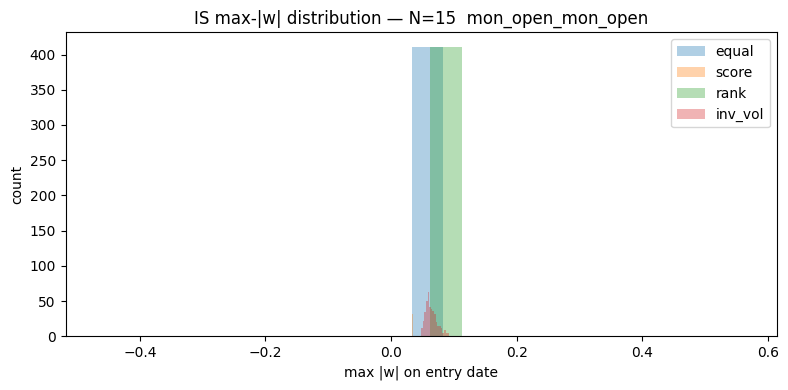

Highest observed single-name |w|: mode='inv_vol'  max=0.0999  p95=0.0833


In [4]:
conc_rows = []
conc_by_mode = {}
for mode in WEIGHT_MODES:
    stats = weight_concentration_stats(results[mode].entry_weights)
    conc_by_mode[mode] = stats
    summary = summarize_concentration(stats)
    summary.name = mode
    conc_rows.append(summary)

conc_summary = pd.DataFrame(conc_rows)
display(conc_summary)

# Distribution of max |w| across IS entry dates (helps size a future cap)
fig, ax = plt.subplots(figsize=(8, 4))
for mode in WEIGHT_MODES:
    s = conc_by_mode[mode]["max_abs_w"].dropna()
    if s.empty:
        continue
    ax.hist(s, bins=20, alpha=0.35, label=mode)
ax.set_xlabel("max |w| on entry date")
ax.set_ylabel("count")
ax.set_title(f"IS max-|w| distribution — N={N_STAR}  {TIMING_STAR}")
ax.legend()
plt.tight_layout()
plt.show()

worst = conc_summary["max_abs_w_max"].idxmax() if len(conc_summary) else None
if worst is not None:
    print(
        f"Highest observed single-name |w|: mode={worst!r}  "
        f"max={conc_summary.loc[worst, 'max_abs_w_max']:.4f}  "
        f"p95={conc_summary.loc[worst, 'max_abs_w_p95']:.4f}"
    )


## 4. Equity overlay


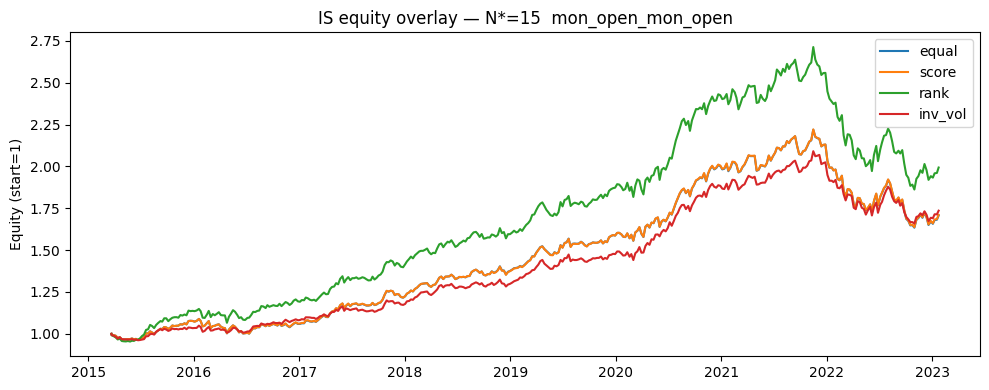

Suggested WEIGHT_STAR=inv_vol — set WEIGHT_STAR='inv_vol' in 05_stop_bakeoff / 06_pct_stop_bakeoff / 07_oos_tearsheet


In [5]:
fig = plot_equity_overlay(
    {m: results[m].equity for m in WEIGHT_MODES},
    title=f"IS equity overlay — N*={N_STAR}  {TIMING_STAR}",
)
plt.show()

print(
    f"Suggested WEIGHT_STAR={WEIGHT_STAR} — set WEIGHT_STAR={WEIGHT_STAR!r} in 05_stop_bakeoff / 06_pct_stop_bakeoff / 07_vol_target_bakeoff / 08_oos_tearsheet"
)


## 5. Inv-vol window screen (IS)

Fix weight mode to **`inv_vol`**. Screen open-to-open vol windows on **research IS
only** (argmax IS net Sharpe). OOS is not used — same freeze discipline as
notebooks 01 / 02 / 05.


window= 5: sharpe=0.850  cagr=6.660%  dd=-15.839%  turn=0.332
window=10: sharpe=0.853  cagr=6.630%  dd=-18.542%  turn=0.235
window=21: sharpe=0.922  cagr=7.245%  dd=-20.662%  turn=0.189
window=42: sharpe=0.938  cagr=7.379%  dd=-20.990%  turn=0.169
window=63: sharpe=0.906  cagr=7.087%  dd=-21.382%  turn=0.162


,n,timing_mode,sharpe,cagr,total_return,max_drawdown,vol,win_rate,mean_turnover,n_periods
inv_vol_window,,,,,,,,,,
42,15,mon_open_mon_open,0.938172,0.073793,0.753056,-0.209901,0.079294,0.602439,0.169383,410
21,15,mon_open_mon_open,0.921772,0.072451,0.735863,-0.206625,0.079350,0.609756,0.189361,410
63,15,mon_open_mon_open,0.905928,0.070865,0.715722,-0.213822,0.079080,0.602439,0.161947,410
10,15,mon_open_mon_open,0.852897,0.066296,0.658846,-0.185419,0.078964,0.592683,0.235453,410
5,15,mon_open_mon_open,0.849794,0.066597,0.662539,-0.158387,0.079644,0.580488,0.332188,410


Suggested INV_VOL_WINDOW_STAR=42  (IS net Sharpe=0.9382)
If WEIGHT_STAR is inv_vol, copy INV_VOL_WINDOW_STAR into 05_stop_bakeoff / 06_pct_stop_bakeoff / 07_oos_tearsheet.


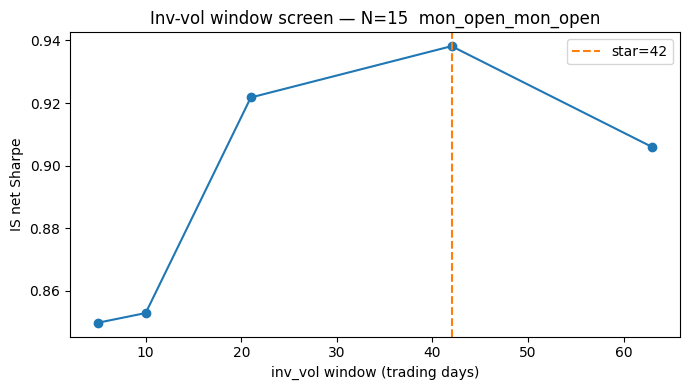

Suggested INV_VOL_WINDOW_STAR=42 — use with WEIGHT_STAR='inv_vol' when mode is inv_vol


In [6]:
vol_results = {}
vol_rows = []
for w in INV_VOL_WINDOWS:
    res = run_backtest(
        scores,
        opens,
        closes,
        n=N_STAR,
        timing_mode=TIMING_STAR,
        weight_mode=WEIGHT_INV_VOL,
        inv_vol_window=w,
        costs=DEFAULT_COSTS,
        date_mask=is_mask,
    )
    vol_results[w] = res
    sm = summarize_periods(res.period_returns)
    vol_rows.append(
        {
            "inv_vol_window": w,
            "n": N_STAR,
            "timing_mode": TIMING_STAR,
            "sharpe": sm["sharpe"],
            "cagr": sm["cagr"],
            "total_return": sm["total_return"],
            "max_drawdown": sm["max_drawdown"],
            "vol": sm["vol"],
            "win_rate": sm["win_rate"],
            "mean_turnover": float(res.turnover.mean()) if len(res.turnover) else np.nan,
            "n_periods": sm["n_periods"],
        }
    )
    print(
        f"window={w:>2}: sharpe={sm['sharpe']:.3f}  cagr={sm['cagr']:.3%}  "
        f"dd={sm['max_drawdown']:.3%}  turn={res.turnover.mean():.3f}"
    )

vol_df = pd.DataFrame(vol_rows).set_index("inv_vol_window")
display(vol_df.sort_values("sharpe", ascending=False))

INV_VOL_WINDOW_STAR = int(vol_df["sharpe"].idxmax())
print(
    f"Suggested INV_VOL_WINDOW_STAR={INV_VOL_WINDOW_STAR}  "
    f"(IS net Sharpe={vol_df.loc[INV_VOL_WINDOW_STAR, 'sharpe']:.4f})"
)
print(
    "If WEIGHT_STAR is inv_vol, copy INV_VOL_WINDOW_STAR into 05_stop_bakeoff / 06_pct_stop_bakeoff / 07_vol_target_bakeoff / 08_oos_tearsheet."
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(vol_df.index.astype(int), vol_df["sharpe"], marker="o")
ax.axvline(INV_VOL_WINDOW_STAR, color="C1", ls="--", label=f"star={INV_VOL_WINDOW_STAR}")
ax.set_xlabel("inv_vol window (trading days)")
ax.set_ylabel("IS net Sharpe")
ax.set_title(f"Inv-vol window screen — N={N_STAR}  {TIMING_STAR}")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Suggested INV_VOL_WINDOW_STAR={INV_VOL_WINDOW_STAR} — "
    f"use with WEIGHT_STAR={WEIGHT_STAR!r} when mode is inv_vol"
)
